<a href="https://colab.research.google.com/github/jigeshak16/Mood_Based_Playlist_Generator-/blob/main/Mood_Based_Playlist_Generator_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install Gradio**

In [ ]:
 # Gradio lets us build a simple web interface inside Colab
 !pip install gradio -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#  Upload & Load Dataset
df = pd.read_csv('/content/Spotify Tracks Dataset.csv')
print(f"📊 Shape: {df.shape}")
print(f"\n🔍 Columns: {df.columns.tolist()}")
df.head()

📊 Shape: (100828, 21)

🔍 Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


# **Clean Data & Assign Mood Labels**

In [ ]:
# Audio features we'll use
features = ['valence', 'energy', 'tempo',
            'danceability', 'loudness', 'acousticness']

# Drop rows with missing values
df = df.dropna(subset=features)

# Remove duplicates
df = df.drop_duplicates()

# Mood labelling based on valence + energy
def assign_mood(row):
    v = row['valence']   # 0-1, higher = more positive
    e = row['energy']    # 0-1, higher = more intense

    if v >= 0.6 and e >= 0.6:
        return 'Happy'
    elif v < 0.4 and e < 0.4:
        return 'Sad'
    elif e >= 0.6 and v < 0.6:
        return 'Energetic'
    else:
        return 'Calm'

df['mood'] = df.apply(assign_mood, axis=1)

print("✅ Mood labels assigned!")
print("\n🎭 Mood Distribution:")
print(df['mood'].value_counts())

✅ Mood labels assigned!

🎭 Mood Distribution:
mood
Energetic    36416
Happy        26443
Calm         25677
Sad          12291
Name: count, dtype: int64


# **Visualise Mood Distribution**

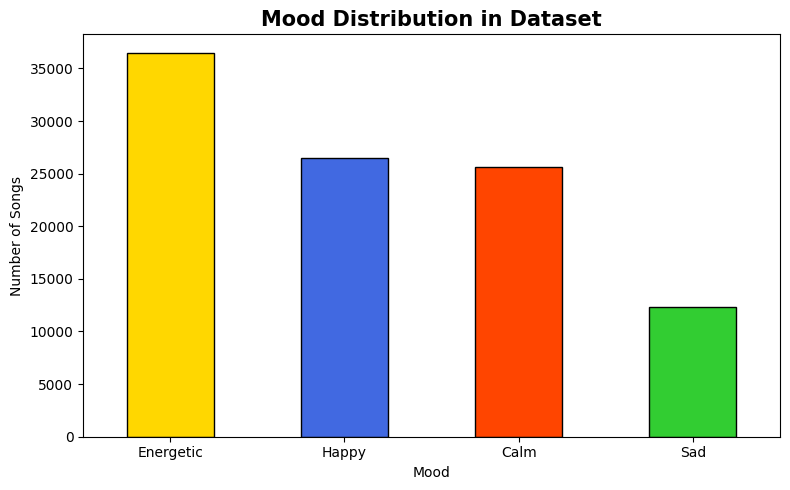

In [ ]:
plt.figure(figsize=(8, 5))
colors = ['#FFD700', '#4169E1', '#FF4500', '#32CD32']

df['mood'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Mood Distribution in Dataset', fontsize=15, fontweight='bold')
plt.xlabel('Mood')
plt.ylabel('Number of Songs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# **Feature Correlation Heatmap**

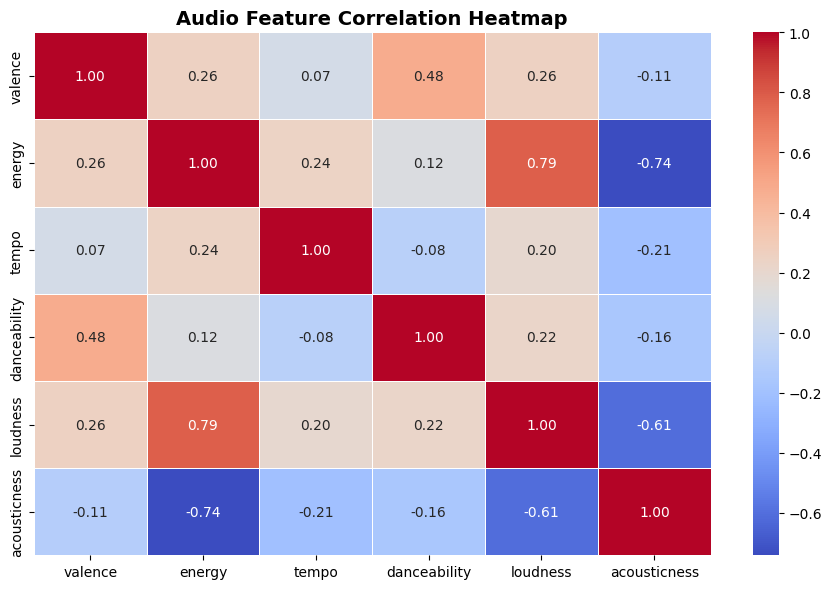

In [ ]:
plt.figure(figsize=(9, 6))

corr_df = df[features].corr()
sns.heatmap(corr_df, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)

plt.title('Audio Feature Correlation Heatmap',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Feature Distribution by Mood**

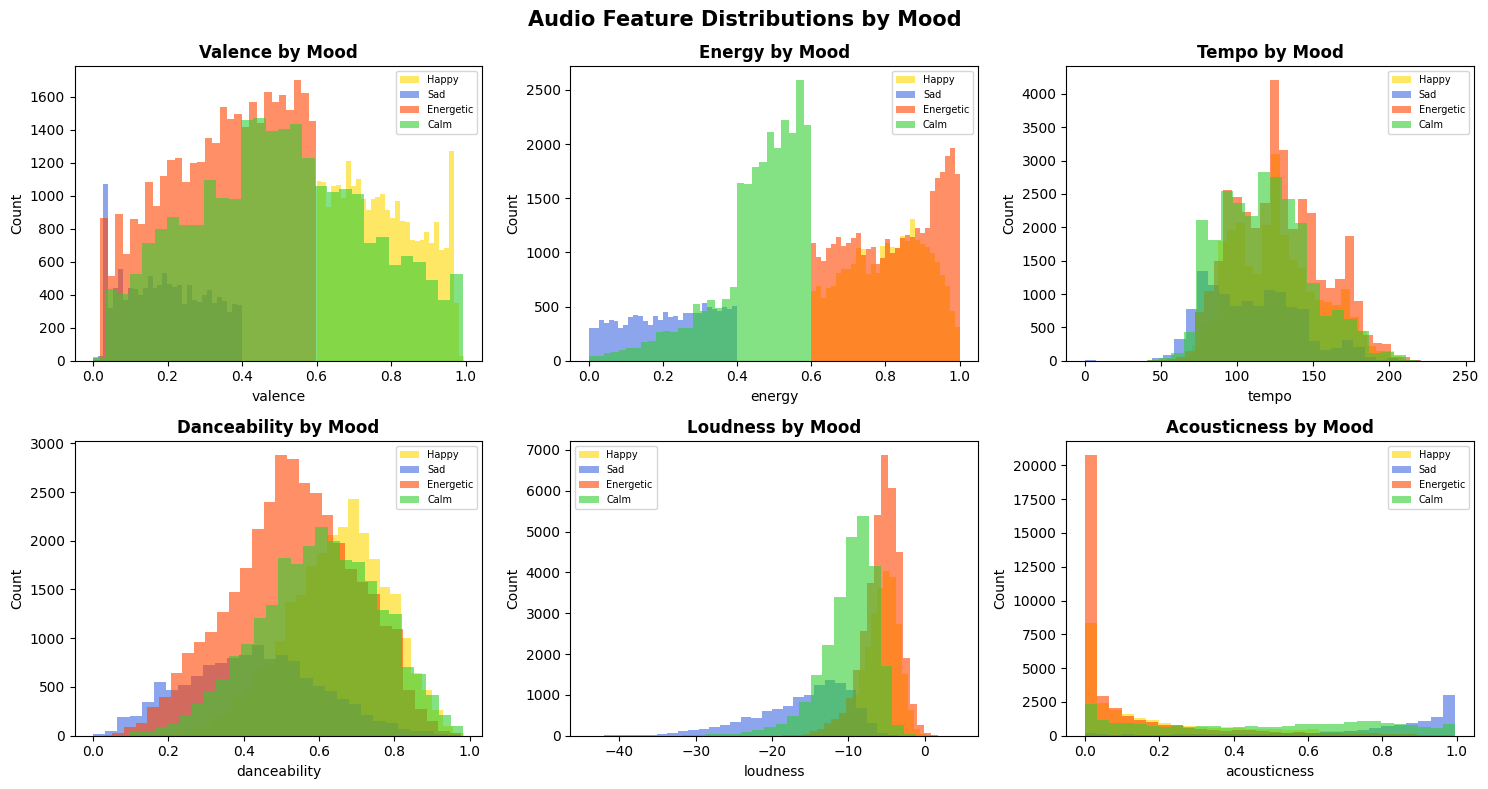

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

mood_colors = {
    'Happy':    '#FFD700',
    'Sad':      '#4169E1',
    'Energetic':'#FF4500',
    'Calm':     '#32CD32'
}

for i, feature in enumerate(features):
    for mood, color in mood_colors.items():
        subset = df[df['mood'] == mood][feature]
        axes[i].hist(subset, bins=30, alpha=0.6,
                     label=mood, color=color, edgecolor='none')
    axes[i].set_title(f'{feature.capitalize()} by Mood',
                      fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

plt.suptitle('Audio Feature Distributions by Mood',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# **Preprocess & Split Data**

In [ ]:
# Encode mood labels to numbers
le = LabelEncoder()
df['mood_encoded'] = le.fit_transform(df['mood'])

print("🏷️ Mood encoding:")
for i, mood in enumerate(le.classes_):
    print(f"   {mood} → {i}")

# X = features, y = mood
X = df[features].values
y = df['mood_encoded'].values

# Normalise (important for KNN and SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Training samples : {X_train.shape[0]}")
print(f"✅ Testing samples  : {X_test.shape[0]}")

🏷️ Mood encoding:
   Calm → 0
   Energetic → 1
   Happy → 2
   Sad → 3

✅ Training samples : 80661
✅ Testing samples  : 20166


# **Train All 4 Models**

In [ ]:
models = {
    'K-Nearest Neighbours' : KNeighborsClassifier(n_neighbors=7),
    'Support Vector Machine': SVC(kernel='rbf', C=1.0,
                                   probability=True, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=200,
                                                      random_state=42,
                                                      n_jobs=-1),
    'Neural Network'        : MLPClassifier(hidden_layer_sizes=(128, 64),
                                             max_iter=300,
                                             random_state=42)
}

results = {}

print("🔄 Training models — please wait...\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    results[name] = {
        'model'      : model,
        'accuracy'   : acc,
        'predictions': y_pred
    }
    print(f"✅ {name:<30} Accuracy: {acc*100:.2f}%")

🔄 Training models — please wait...

✅ K-Nearest Neighbours           Accuracy: 95.72%
✅ Support Vector Machine         Accuracy: 98.69%
✅ Random Forest                  Accuracy: 100.00%
✅ Neural Network                 Accuracy: 99.56%


# **Accuracy Comparison Chart**

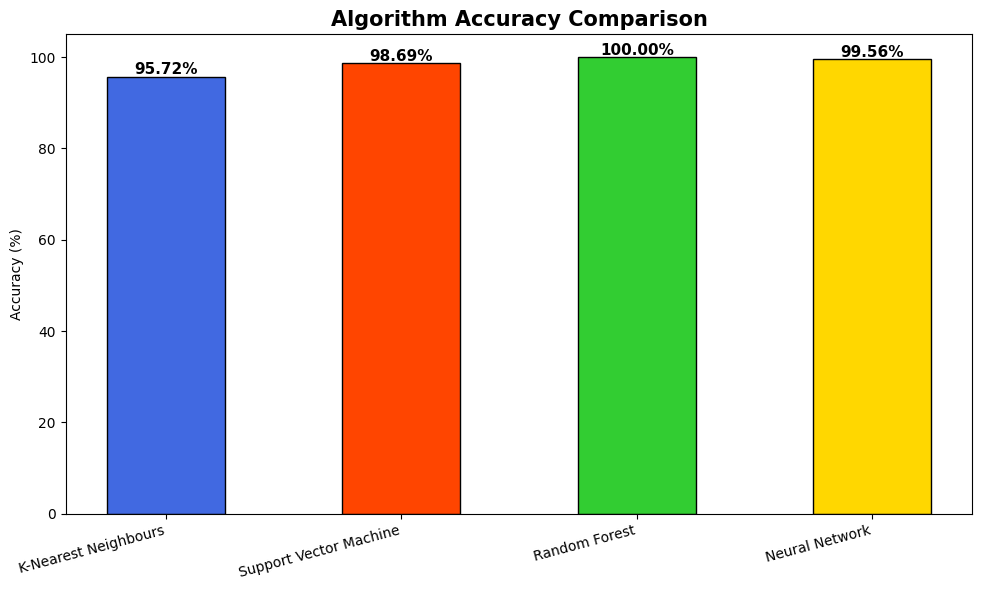


🏆 Best Model: Random Forest (100.00%)


In [ ]:
plt.figure(figsize=(10, 6))

algo_names = list(results.keys())
accuracies = [results[n]['accuracy'] * 100 for n in algo_names]
bar_colors = ['#4169E1', '#FF4500', '#32CD32', '#FFD700']

bars = plt.bar(algo_names, accuracies,
               color=bar_colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%',
             ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, 105)
plt.title('Algorithm Accuracy Comparison',
          fontsize=15, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Print best model
best_name = max(results, key=lambda n: results[n]['accuracy'])
print(f"\n🏆 Best Model: {best_name} "
      f"({results[best_name]['accuracy']*100:.2f}%)")

# **Detailed Report + Confusion Matrix**


   RANDOM FOREST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Calm       1.00      1.00      1.00      5136
   Energetic       1.00      1.00      1.00      7283
       Happy       1.00      1.00      1.00      5289
         Sad       1.00      1.00      1.00      2458

    accuracy                           1.00     20166
   macro avg       1.00      1.00      1.00     20166
weighted avg       1.00      1.00      1.00     20166



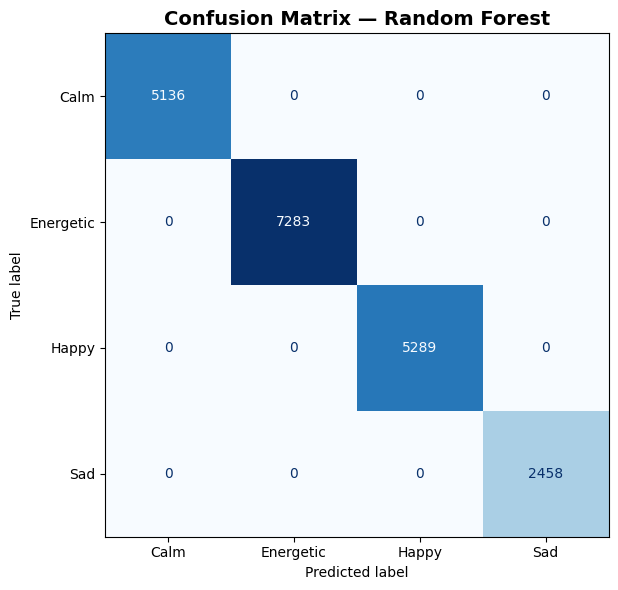

In [ ]:
# Use Random Forest for detailed evaluation
best_pred = results['Random Forest']['predictions']

print("=" * 55)
print("   RANDOM FOREST — CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, best_pred,
                              target_names=le.classes_))

# Confusion Matrix
cm   = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Feature Importance**

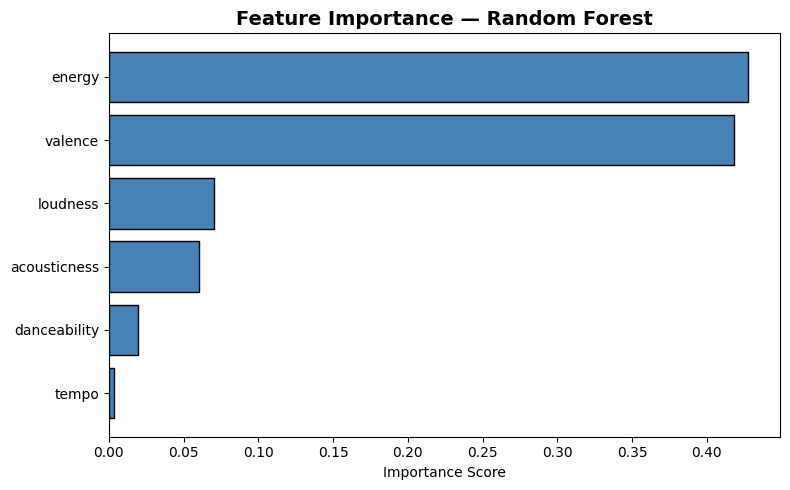

In [ ]:
rf_model     = results['Random Forest']['model']
importances  = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='steelblue', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest',
           fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Playlist Generator Function**

In [ ]:
def generate_playlist(mood, n=10):
    mood_songs = df[df['mood'] == mood].copy()

    # Pick display columns (whatever exists in your dataset)
    display_cols = []
    for col in ['track_name', 'artists',
                'album_name', 'popularity']:
        if col in mood_songs.columns:
            display_cols.append(col)

    # Sort by popularity if available
    if 'popularity' in mood_songs.columns:
        playlist = (mood_songs
                    .sort_values('popularity', ascending=False)
                    .head(n)[display_cols]
                    .reset_index(drop=True))
    else:
        playlist = (mood_songs
                    .sample(n=min(n, len(mood_songs)), random_state=42)
                    [display_cols]
                    .reset_index(drop=True))

    playlist.index += 1
    return playlist

# Quick test
print("🎵 Sample Happy Playlist:")
print(generate_playlist('Happy', n=5))

🎵 Sample Happy Playlist:
        track_name        artists  \
1       La Bachata  Manuel Turizo   
2       La Bachata  Manuel Turizo   
3       La Bachata  Manuel Turizo   
4       La Bachata  Manuel Turizo   
5  I Ain't Worried    OneRepublic   

                                          album_name  popularity  
1                                         La Bachata          98  
2                                         La Bachata          98  
3                                         La Bachata          98  
4                                         La Bachata          98  
5  I Ain’t Worried (Music From The Motion Picture...          96  


# **Launch Gradio UI**

In [ ]:
# HOW IT WORKS:
# 1. User adjusts sliders to describe a song's audio features
# 2. Our trained Random Forest model predicts the mood
# 3. A playlist of matching songs is shown
# 4. Confidence scores show how sure the model is

import gradio as gr

# ── Mood metadata ─────────────────────────────────────────
MOOD_EMOJI = {
    'Happy':     '😊',
    'Sad':       '😢',
    'Energetic': '⚡',
    'Calm':      '😌'
}

MOOD_DESC = {
    'Happy':     'Upbeat, joyful songs — great for celebrations & good vibes',
    'Sad':       'Emotional, slow songs — for reflective or melancholic moments',
    'Energetic': 'High-intensity songs — perfect for workouts & hype sessions',
    'Calm':      'Peaceful, relaxing songs — ideal for studying or winding down'
}

# Use our best trained model (Random Forest)
rf_model = results['Random Forest']['model']


# ── Core prediction function ──────────────────────────────
def predict_mood(valence, energy, tempo,
                 danceability, loudness, acousticness, n_songs):
    """
    Takes slider values → predicts mood → returns playlist.
    This function is called every time the user clicks the button.
    """

    # Step 1 — Package the slider values into the correct format
    # Must match the exact feature order used during training
    input_data = np.array([[
        valence, energy, tempo,
        danceability, loudness, acousticness
    ]])

    # Step 2 — Apply the SAME scaler used during training
    # IMPORTANT: use transform() not fit_transform() here
    # because we don't want to re-learn the scaling from 1 song
    input_scaled = scaler.transform(input_data)

    # Step 3 — Predict mood using Random Forest
    pred_encoded   = rf_model.predict(input_scaled)[0]
    predicted_mood = le.inverse_transform([pred_encoded])[0]
    # le.inverse_transform converts number back to mood name

    # Step 4 — Get probability/confidence for each mood class
    proba = rf_model.predict_proba(input_scaled)[0]
    # proba is an array like [0.05, 0.10, 0.75, 0.10]
    # (one probability per mood class, they sum to 1.0)

    # Step 5 — Build the result text (shown on the right panel)
    emoji = MOOD_EMOJI.get(predicted_mood, '')
    desc  = MOOD_DESC.get(predicted_mood, '')

    # Sort moods by confidence (highest first)
    mood_probs = sorted(
        zip(le.classes_, proba),
        key=lambda x: -x[1]
    )

    confidence_lines = "\n".join([
        f"{MOOD_EMOJI.get(m,'')} **{m}** — {p*100:.1f}% confidence"
        for m, p in mood_probs
    ])

    result_text = (
        f"## {emoji} Predicted Mood: **{predicted_mood}**\n\n"
        f"_{desc}_\n\n"
        f"---\n"
        f"### 🎯 Confidence Scores:\n"
        f"{confidence_lines}"
    )

    # Step 6 — Generate playlist for the predicted mood
    playlist = generate_playlist(predicted_mood, n=int(n_songs))

    return result_text, playlist


# ── Build the Gradio Interface ────────────────────────────
with gr.Blocks(
    theme=gr.themes.Soft(),
    title="🎵 Mood-Based Playlist Generator"
) as demo:

    # ── Header ────────────────────────────────────────────
    gr.Markdown("""
    # 🎵 Mood-Based Playlist Generator
    ### Supervised Machine Learning Project — SML Class
    ---
    **How to use:** Adjust the audio feature sliders on the left
    to describe a song, then click **Generate Playlist**.
    The model will predict the song's mood and show matching songs!
    """)

    # ── Main Layout: Two Columns ──────────────────────────
    with gr.Row():

        # LEFT COLUMN — Input sliders
        with gr.Column(scale=1):
            gr.Markdown("### 🎚️ Adjust Audio Features")
            gr.Markdown("_Move sliders to describe your song_")

            valence = gr.Slider(
                minimum=0, maximum=1,
                value=0.7, step=0.01,
                label="🎭 Valence (0=Negative Tone → 1=Positive Tone)"
            )
            energy = gr.Slider(
                minimum=0, maximum=1,
                value=0.8, step=0.01,
                label="⚡ Energy (0=Calm & Soft → 1=Intense & Loud)"
            )
            tempo = gr.Slider(
                minimum=60, maximum=200,
                value=120, step=1,
                label="🥁 Tempo in BPM (60=Slow → 200=Very Fast)"
            )
            danceability = gr.Slider(
                minimum=0, maximum=1,
                value=0.75, step=0.01,
                label="💃 Danceability (0=Hard to Dance → 1=Very Danceable)"
            )
            loudness = gr.Slider(
                minimum=-60, maximum=0,
                value=-5, step=0.1,
                label="🔊 Loudness in dB (-60=Very Quiet → 0=Very Loud)"
            )
            acousticness = gr.Slider(
                minimum=0, maximum=1,
                value=0.1, step=0.01,
                label="🎸 Acousticness (0=Electric/Synth → 1=Acoustic)"
            )
            n_songs = gr.Slider(
                minimum=5, maximum=20,
                value=10, step=1,
                label="📋 Number of Songs in Playlist"
            )

            # Generate button
            btn = gr.Button(
                "🎵 Generate My Playlist",
                variant="primary",   # Makes it blue/highlighted
                size="lg"            # Large button
            )

        # RIGHT COLUMN — Output results
        with gr.Column(scale=2):
            gr.Markdown("### 🎭 Mood Prediction Result")
            mood_output = gr.Markdown(
                value="_Your mood prediction will appear here..._"
            )

            gr.Markdown("### 📋 Your Personalised Playlist")
            playlist_output = gr.Dataframe(
                wrap=True,           # Wrap long text in cells
                label="Songs matched to your mood"
            )

    # ── Connect Button to Function ────────────────────────
    btn.click(
        fn=predict_mood,             # Function to call on click
        inputs=[                     # What to pass to the function
            valence, energy, tempo,
            danceability, loudness,
            acousticness, n_songs
        ],
        outputs=[mood_output, playlist_output]  # Where to show results
    )

    # ── Quick Preset Examples ─────────────────────────────
    gr.Markdown("---")
    gr.Markdown("### 💡 Quick Examples — Try These Settings:")
    gr.Markdown("""
    | Mood | Valence | Energy | Tempo | Try it for... |
    |------|---------|--------|-------|---------------|
    | 😊 Happy | 0.8 | 0.85 | 130 | Morning commute, parties |
    | 😢 Sad | 0.2 | 0.2 | 65 | Rainy days, breakups |
    | ⚡ Energetic | 0.5 | 0.9 | 155 | Gym, running, gaming |
    | 😌 Calm | 0.6 | 0.3 | 85 | Studying, sleeping, reading |
    """)

# ── Launch the App ────────────────────────────────────────
# share=True → generates a public link anyone can open
print("🚀 Launching Gradio app...")
print("📌 Look for the public URL below — copy it for your demo!\n")
demo.launch(share=True)

🚀 Launching Gradio app...
📌 Look for the public URL below — copy it for your demo!

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://930bb6196fdac44391.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
